In [1]:
#!pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets
flights = pd.read_csv("flights.csv")
airlines = pd.read_csv("airlines.csv")
airports = pd.read_csv("airports.csv")

flights.head()

C:\Users\salem\AppData\Local\Temp\ipykernel_13564\1265686048.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check for missing values in each column
flights.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [5]:
# Display summary statistics
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


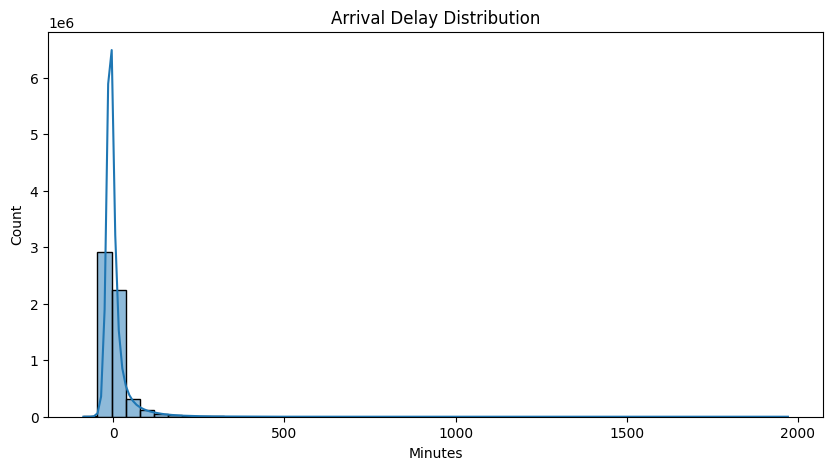

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(flights["ARRIVAL_DELAY"].dropna(), bins=50, kde=True)
plt.title("Arrival Delay Distribution")
plt.xlabel("Minutes")
plt.show()

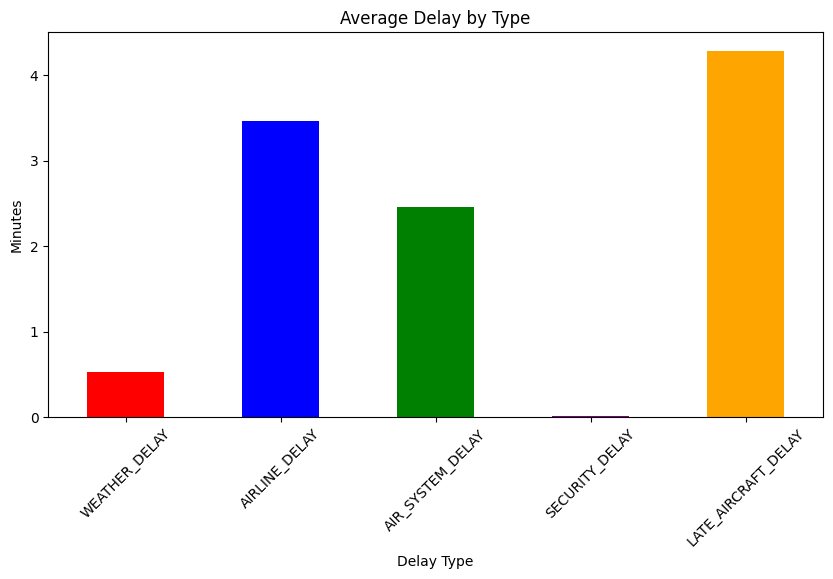

In [8]:
# Define the correct delay type column names
delay_types = ['WEATHER_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

# Filter dataset to avoid NaN values in delay columns
flights[delay_types] = flights[delay_types].fillna(0)

# Plot the average delay per type
plt.figure(figsize=(10, 5))
flights[delay_types].mean().plot(kind='bar', color=['red', 'blue', 'green', 'purple', 'orange'])
plt.title('Average Delay by Type')
plt.ylabel('Minutes')
plt.xlabel('Delay Type')
plt.xticks(rotation=45)
plt.show()

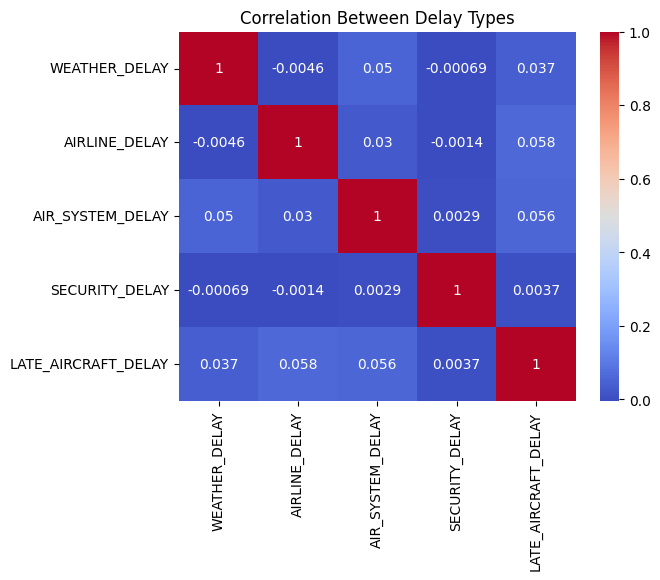

In [9]:
## Correlation Between Delay Types
sns.heatmap(flights[delay_types].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Delay Types')
plt.show()


## Route Analysis

In [ ]:
## Most Frequent Routes
route_counts = flights.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).size().reset_index(name='Count')
print(route_counts.sort_values(by='Count', ascending=False).head(10))


      ORIGIN_AIRPORT DESTINATION_AIRPORT  Count
11867            SFO                 LAX  13744
10165            LAX                 SFO  13457
9949             JFK                 LAX  12016
10130            LAX                 JFK  12015
10053            LAS                 LAX   9715
10253            LGA                 ORD   9639
10132            LAX                 LAS   9594
11085            ORD                 LGA   9575
11864            SFO                 JFK   8440
9974             JFK                 SFO   8437


In [14]:
## Routes with Highest Delay Rates
delay_routes = flights.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['ARRIVAL_DELAY'].mean().reset_index()
delay_routes = delay_routes.sort_values(by='ARRIVAL_DELAY', ascending=False)
print(delay_routes.head(10))

      ORIGIN_AIRPORT DESTINATION_AIRPORT  ARRIVAL_DELAY
9688             IAD                 TTN          381.0
7410           14869               13264          268.0
12200            SWF                 PBI          260.5
5997           13158               11298          248.0
11537            RIC                 CAE          228.0
11515            RDU                 IND          208.0
5081           11433               13303          203.4
5571           12266               14262          188.0
5443           12191               14843          182.0
7489           14960               11298          173.5


## Airline Performance


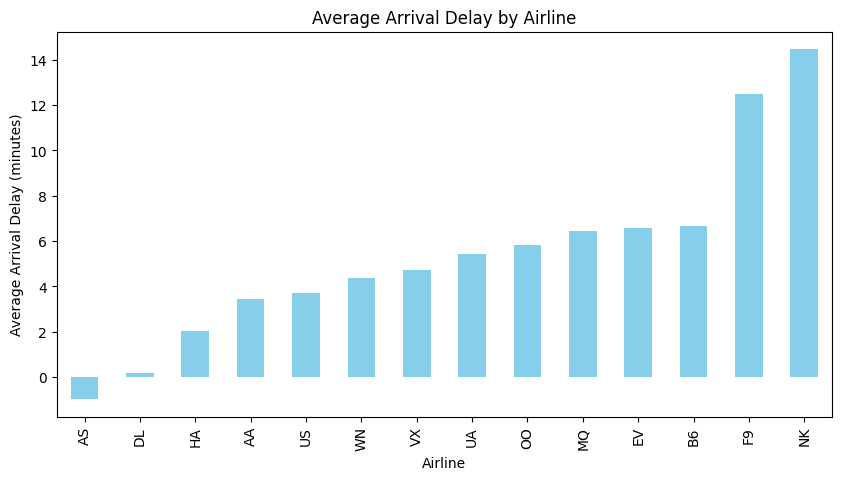

In [16]:
on_time_performance = flights.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()
on_time_performance.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.show()


In [17]:
## Monthly Trends
flights['Month'] = pd.to_datetime(flights['FlightDate']).dt.month
sns.boxplot(x='Month', y='ArrDelay', data=flights)
plt.title('Monthly Delay Patterns')
plt.show()

KeyError: 'FlightDate'